Objective

The objective is to classify five static hand gestures using a self-collected image dataset: fist, open palm, peace, point up, and thumbs up.
Two approaches are compared: a simple convolutional neural network trained from scratch and transfer learning with MobileNetV2. The workflow includes data inspection, preprocessing, augmentation, participant-based splitting, training, and evaluation.
The project investigates recognition of five predefined gestures. It does not perform sign language translation.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os
import json
import hashlib
import shutil
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from IPython.display import display

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    ConfusionMatrixDisplay
)

SEED = 42
keras.utils.set_random_seed(SEED)

PROJECT = Path("/content/drive/MyDrive/CV_project")
PROJECT.mkdir(parents=True, exist_ok=True)

RUN_ID = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
OUTPUT = PROJECT / f"results_{RUN_ID}"
OUTPUT.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (160, 160)
BATCH_SIZE = 16

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Results folder:", OUTPUT)

2. Dataset Structure

Each class folder contains images from three participants, stored in folders named person_001, person_002, and person_003. Participant identifiers refer to the same people across all five classes.
Class labels are inferred from folder names. Therefore, correct folder organization is essential for supervised learning.

In [ ]:
ZIP_PATH = PROJECT / "hand_gestures.zip"

assert ZIP_PATH.exists(), (
    f"ZIP not found: {ZIP_PATH}\n"
    "Check the filename and its location in Google Drive."
)

RAW = Path("/content") / f"gesture_raw_{RUN_ID}"
RAW.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH) as archive:
    root = RAW.resolve()

    for member in archive.infolist():
        target = (RAW / member.filename).resolve()
        if not target.is_relative_to(root):
            raise ValueError(f"Unsafe ZIP path: {member.filename}")

    archive.extractall(RAW)

print("Extracted folders:")
for folder in sorted(RAW.rglob("*")):
    if (
        folder.is_dir()
        and "__MACOSX" not in folder.parts
        and len(folder.relative_to(RAW).parts) <= 3
    ):
        print(folder.relative_to(RAW))

Extracted folders:
hand_dataset
hand_dataset/fist ✊
hand_dataset/fist ✊/person_001
hand_dataset/fist ✊/person_002
hand_dataset/fist ✊/person_003
hand_dataset/open_palm ✋
hand_dataset/open_palm ✋/person_001
hand_dataset/open_palm ✋/person_002
hand_dataset/open_palm ✋/person_003
hand_dataset/peace ✌️
hand_dataset/peace ✌️/person_001
hand_dataset/peace ✌️/person_002
hand_dataset/peace ✌️/person_003
hand_dataset/point_up 👆
hand_dataset/point_up 👆/person_001
hand_dataset/point_up 👆/person_002
hand_dataset/point_up 👆/person_003
hand_dataset/thumbs_up👍
hand_dataset/thumbs_up👍/person_001
hand_dataset/thumbs_up👍/person_002
hand_dataset/thumbs_up👍/person_003


In [ ]:
def visible_dirs(folder):
    return sorted(
        p for p in folder.iterdir()
        if p.is_dir()
        and not p.name.startswith(".")
        and p.name != "__MACOSX"
    )

DATA_ROOT = RAW

while len(visible_dirs(DATA_ROOT)) == 1:
    DATA_ROOT = visible_dirs(DATA_ROOT)[0]

CLASS_NAMES = [p.name for p in visible_dirs(DATA_ROOT)]
NUM_CLASSES = len(CLASS_NAMES)

print("Dataset folder:", DATA_ROOT)
print("Classes:", CLASS_NAMES)

assert NUM_CLASSES == 5, ()

with open(OUTPUT / "class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f, indent=2)

Dataset folder: /content/gesture_raw_20261002_090401/hand_dataset
Classes: ['fist ✊', 'open_palm ✋', 'peace ✌️', 'point_up 👆', 'thumbs_up👍']


3. Image Inspection and Preprocessing

Images are checked for readability, corrected for EXIF orientation, and converted to RGB. Exact duplicates are identified using a hash of the decoded image dimensions and pixel values. Conflicting labels for identical images require manual review.
Working copies are resized to fit within 160 × 160 pixels and padded to preserve aspect ratio. Original photographs remain unchanged. This duplicate check does not detect all visually similar images.

,usable_images
class_name,
fist ✊,100
open_palm ✋,101
peace ✌️,103
point_up 👆,104
thumbs_up👍,102


Usable images: 510
Issues / duplicates: 0


/tmp/ipykernel_828/1272168928.py:98: UserWarning: Glyph 9994 (\N{RAISED FIST}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/1272168928.py:98: UserWarning: Glyph 9995 (\N{RAISED HAND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/1272168928.py:98: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/1272168928.py:98: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/1272168928.py:99: UserWarning: Glyph 9994 (\N{RAISED FIST}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT / "class_distribution.png", dpi=180)
/tmp/ipykernel_828/1272168928.py:99: UserWarning: Glyph 9995 (\N{RAISED HAND}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT / "class_distribution.png", dpi=180)
/tmp/ipykernel_828/1272168928.py:99: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACKHAND 

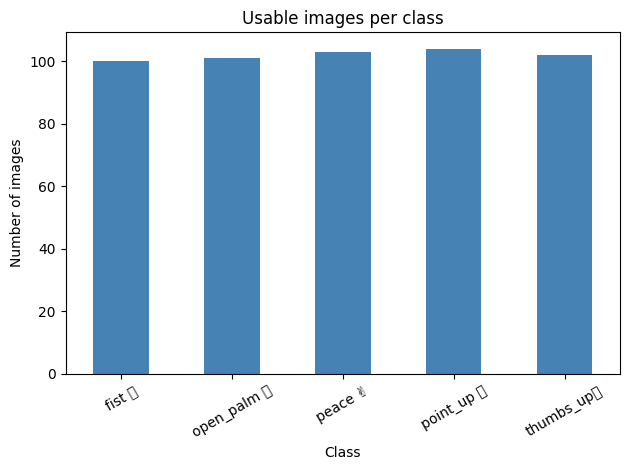

In [ ]:
CLEAN = Path("/content") / f"gesture_clean_{RUN_ID}"
CLEAN.mkdir(parents=True, exist_ok=True)

extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

records = []
issues = []
seen = {}
conflicting_labels = []

for label, class_name in enumerate(CLASS_NAMES):
    class_dir = DATA_ROOT / class_name

    for path in sorted(class_dir.rglob("*")):
        if not path.is_file():
            continue
        if any(part.startswith(".") for part in path.relative_to(DATA_ROOT).parts):
            continue
        if path.suffix.lower() not in extensions:
            issues.append({"file": str(path), "issue": "unsupported file type"})
            continue

        relative = path.relative_to(class_dir)

        group = relative.parts[0] if len(relative.parts) > 1 else None

        try:
            with Image.open(path) as original:
                im = ImageOps.exif_transpose(original).convert("RGB")
                width, height = im.size

                digest = hashlib.sha256(
                    str(im.size).encode() + im.tobytes()).hexdigest()

                if digest in seen:
                    previous_class = seen[digest]
                    issues.append({
                        "file": str(path),
                        "issue": f"exact duplicate of image in {previous_class}"})
                    if previous_class != class_name:
                        conflicting_labels.append(str(path))
                    continue

                seen[digest] = class_name

                destination = CLEAN / f"{digest}.png"
                im = ImageOps.pad(
                    im, IMG_SIZE,
                    method=Image.Resampling.LANCZOS,
                    color=(0, 0, 0))
                im.save(destination)

                records.append({
                    "path": str(destination),
                    "source": str(path.relative_to(DATA_ROOT)),
                    "class_name": class_name,
                    "label": label,
                    "group": group,
                    "width": width,
                    "height": height,
                    "hash": digest})

        except Exception as error:
            issues.append({"file": str(path), "issue": str(error)})

df = pd.DataFrame(records)
pd.DataFrame(issues, columns=["file", "issue"]).to_csv(
    OUTPUT / "data_issues.csv", index=False
)

assert len(df) > 0, "No readable images found."
assert not conflicting_labels, (
    "Identical images have different class labels. "
    "Check data_issues.csv, fix the original dataset, and restart."
)

counts = df.groupby("class_name").size().reindex(CLASS_NAMES, fill_value=0)
display(counts.rename("usable_images").to_frame())

print("Usable images:", len(df))
print("Issues / duplicates:", len(issues))

if len(issues):
    display(pd.DataFrame(issues).head(15))

assert (counts >= 3).all(), "A class has too few usable images."

if (counts < 100).any():
    print("WARNING: Some classes have fewer than 100 usable images.")

counts.to_csv(OUTPUT / "class_counts.csv")

counts.plot.bar(color="steelblue")
plt.title("Usable images per class")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT / "class_distribution.png", dpi=180)
plt.show()

4. Participant-Based Split

Person_001 is used for training, person_002 for validation, and person_003 for testing. This prevents images of the same participant from appearing in multiple subsets.

The split prioritizes separation between people rather than fixed percentage ratios. Each subset must contain all five classes. Because only one participant is used for training and one for testing, the experiment provides a limited assessment of performance on new people.

/tmp/ipykernel_828/4048141629.py:15: UserWarning: Glyph 9994 (\N{RAISED FIST}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/4048141629.py:15: UserWarning: Glyph 9995 (\N{RAISED HAND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/4048141629.py:15: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/4048141629.py:15: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/4048141629.py:16: UserWarning: Glyph 9994 (\N{RAISED FIST}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT / "dataset_examples.png", dpi=180)
/tmp/ipykernel_828/4048141629.py:16: UserWarning: Glyph 9995 (\N{RAISED HAND}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT / "dataset_examples.png", dpi=180)
/tmp/ipykernel_828/4048141629.py:16: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACKHAND INDE

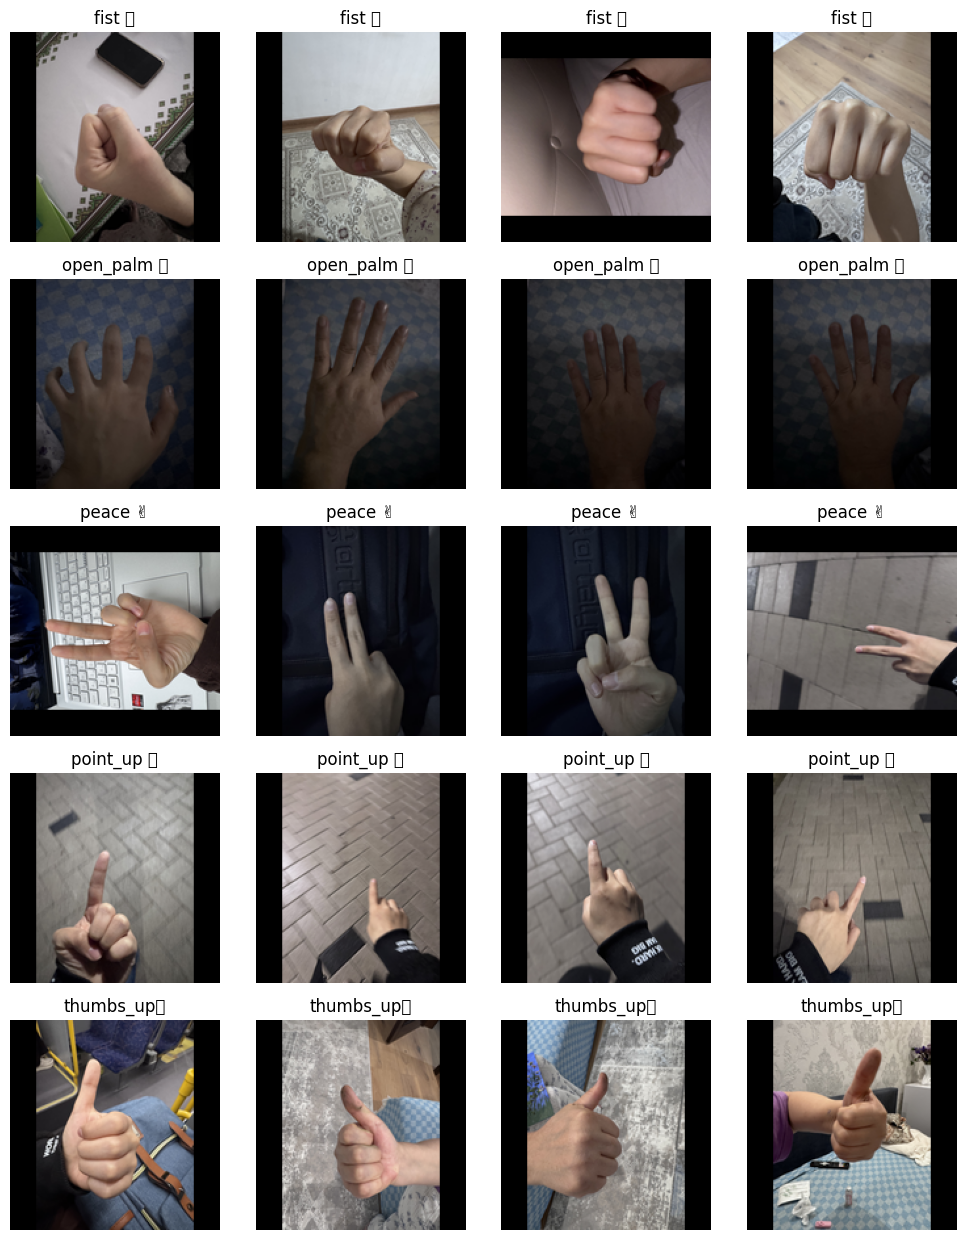

In [ ]:
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(10, 2.5 * NUM_CLASSES))

for row, class_name in enumerate(CLASS_NAMES):
    subset = df[df["class_name"] == class_name]
    examples = subset.sample(min(4, len(subset)), random_state=SEED)

    for col in range(4):
        axes[row, col].axis("off")

    for col, (_, item) in enumerate(examples.iterrows()):
        with Image.open(item["path"]) as im:
            axes[row, col].imshow(im)
        axes[row, col].set_title(class_name)

plt.tight_layout()
plt.savefig(OUTPUT / "dataset_examples.png", dpi=180)
plt.show()

In [ ]:
people = ["person_001", "person_002", "person_003"]

fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(10, 13))

for row, class_name in enumerate(CLASS_NAMES):
    for col, person in enumerate(people):
        subset = df[
            (df["class_name"] == class_name) &
            (df["group"] == person)
        ]

        example = subset.sample(1, random_state=SEED).iloc[0]

        with Image.open(example["path"]) as image:
            axes[row, col].imshow(image)

        axes[row, col].set_title(f"{class_name}\n{person}")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
USE_GROUPS = True

expected_people = ["person_001", "person_002", "person_003"]

assert df["group"].notna().all(), (
    "Some images are outside person folders."
)

print("Detected person folders:", sorted(df["group"].unique()))

assert set(df["group"]) == set(expected_people), (
    "Folder names must be exactly: person_001, person_002, person_003. "
    "Check the detected names above."
)
person_counts = pd.crosstab(
    df["class_name"], df["group"]
).reindex(
    index=CLASS_NAMES,
    columns=expected_people,
    fill_value=0
)

display(person_counts)

assert (person_counts > 0).all().all(), (
    "At least one person has no usable images in one of the classes."
)

train_df = (
    df[df["group"] == "person_001"]
    .copy().reset_index(drop=True)
)

val_df = (
    df[df["group"] == "person_002"]
    .copy().reset_index(drop=True)
)

test_df = (
    df[df["group"] == "person_003"]
    .copy().reset_index(drop=True)
)

manifest = pd.concat([
    train_df.assign(split="train"),
    val_df.assign(split="validation"),
    test_df.assign(split="test")
], ignore_index=True)

assert manifest["hash"].nunique() == len(manifest), (
    "Exact duplicate images remain."
)

manifest.to_csv(OUTPUT / "split_manifest.csv", index=False)
person_counts.to_csv(OUTPUT / "person_class_counts.csv")

split_counts = pd.crosstab(
    manifest["class_name"], manifest["split"]
).reindex(columns=["train", "validation", "test"])

display(split_counts)
split_counts.to_csv(OUTPUT / "split_counts.csv")

print("Train:", len(train_df), "images — person_001")
print("Validation:", len(val_df), "images — person_002")
print("Test:", len(test_df), "images — person_003")

Detected person folders: ['person_001', 'person_002', 'person_003']


group,person_001,person_002,person_003
class_name,,,
fist ✊,77,18,5
open_palm ✋,45,30,26
peace ✌️,50,18,35
point_up 👆,82,13,9
thumbs_up👍,39,37,26


split,train,validation,test
class_name,,,
fist ✊,77,18,5
open_palm ✋,45,30,26
peace ✌️,50,18,35
point_up 👆,82,13,9
thumbs_up👍,39,37,26


Train: 293 images — person_001
Validation: 116 images — person_002
Test: 101 images — person_003


### Preparing the Data for Training

The dataset contains five hand gesture classes: fist, open palm, peace,
point up, and thumbs up. Images are split by participant: person_001
is used for training, person_002 for validation, and person_003 for
testing. This keeps each participant in only one subset.

Images are loaded in batches of 16 at a resolution of 160 × 160 pixels.
Pixel normalization is included inside each model.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def read_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_png(image, channels=3)
    image = tf.cast(image, tf.float32)
    image = tf.ensure_shape(image, (*IMG_SIZE, 3))
    return image, label

def make_dataset(frame, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((
        frame["path"].to_numpy(),
        frame["label"].to_numpy(dtype=np.int32)
    ))
    dataset = dataset.map(read_image, num_parallel_calls=AUTOTUNE)

    if training:
        dataset = dataset.shuffle(
            len(frame), seed=SEED, reshuffle_each_iteration=True
        )

    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Training images: 293
Validation images: 116
Test images: 101


Data Augmentation

Small random rotations, translations, and zoom changes are applied
during training to introduce variation in hand position and orientation.
Validation and test images are not augmented. The augmented examples
are inspected to check that the gesture remains recognizable.

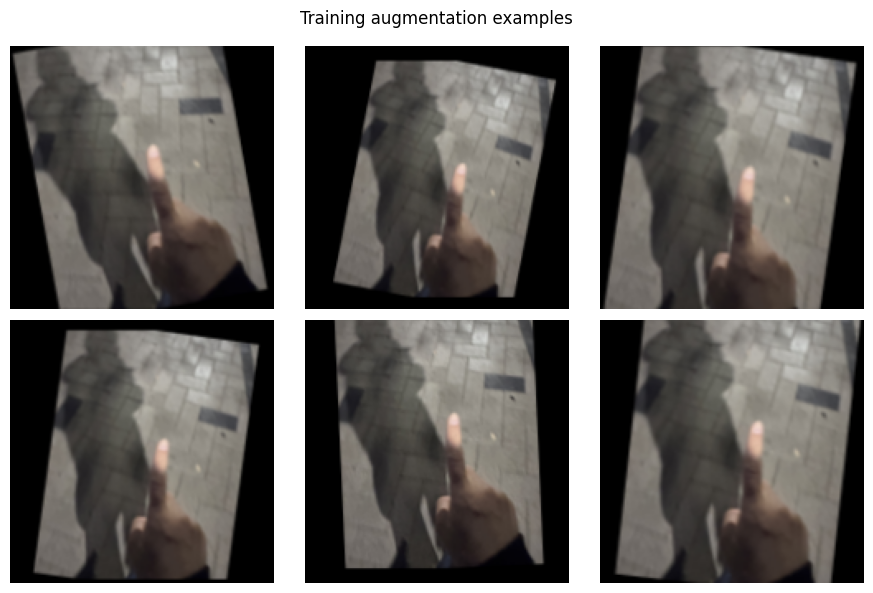

In [ ]:
def make_augmentation():
    return keras.Sequential([
        layers.RandomRotation(0.04, fill_mode="constant"),
        layers.RandomTranslation(0.06, 0.06, fill_mode="constant"),
        layers.RandomZoom(0.10, fill_mode="constant")
    ], name="augmentation")

preview_augmentation = make_augmentation()
images, _ = next(iter(train_ds))

plt.figure(figsize=(9, 6))
for i in range(6):
    augmented = preview_augmentation(images[:1], training=True)[0]
    plt.subplot(2, 3, i + 1)
    plt.imshow(np.clip(augmented.numpy(), 0, 255).astype("uint8"))
    plt.axis("off")

plt.suptitle("Training augmentation examples")
plt.tight_layout()
plt.savefig(OUTPUT / "augmentation_examples.png", dpi=180)
plt.show()

6. Baseline Model: Simple CNN

A convolutional neural network is trained from scratch as the baseline.
It contains three convolutional blocks followed by a classification
head. Pixel values are scaled to [0, 1], and dropout is used to reduce
overfitting.

The model is trained for up to 25 epochs. Early stopping monitors
validation loss, and the checkpoint with the lowest validation loss
is saved.

In [ ]:
def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

def make_callbacks(name):
    return [
        keras.callbacks.ModelCheckpoint(
            str(OUTPUT / f"{name}.keras"),
            monitor="val_loss",
            save_best_only=True
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    ]

keras.utils.set_random_seed(SEED)

baseline = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    make_augmentation(),
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
], name="Baseline_CNN")

compile_model(baseline)
baseline.summary()

history_baseline = baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=make_callbacks("baseline_cnn")
)

pd.DataFrame(history_baseline.history).to_csv(
    OUTPUT / "baseline_history.csv", index=False
)

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,829 (397.77 KB)

 Trainable params: 101,829 (397.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.2355 - loss: 1.6010 - val_accuracy: 0.0603 - val_loss: 1.7045 - learning_rate: 0.0010
Epoch 2/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.2423 - loss: 1.5982 - val_accuracy: 0.1121 - val_loss: 1.6807 - learning_rate: 0.0010
Epoch 3/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.2935 - loss: 1.5906 - val_accuracy: 0.1121 - val_loss: 1.6834 - learning_rate: 0.0010
Epoch 4/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.3003 - loss: 1.5739 - val_accuracy: 0.1552 - val_loss: 1.7441 - learning_rate: 0.0010
Epoch 5/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.2730 - loss: 1.5678 - val_accuracy: 0.1810 - val_loss: 1.7539 - learning_rate: 5.0000e-04
Epoch 6/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.3072 - loss: 1.5573 - val_accuracy: 0.1724 - val_loss: 1.7221 - learning_rate: 5.0000e-04
Epoch 7/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.3208 - loss: 1.5436 - val_ac

7. Transfer Learning with MobileNetV2

MobileNetV2 pretrained on ImageNet is used as a frozen feature extractor. Its original classification head is removed and replaced with a five-class output layer.

Pixels are scaled to [-1, 1]. Only the new classification head is trained. This experiment tests whether pretrained features improve performance compared with training the baseline CNN from scratch.

In [ ]:
keras.utils.set_random_seed(SEED)

base_model = keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = make_augmentation()(inputs)

x = layers.Rescaling(1.0 / 127.5, offset=-1)(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

transfer = keras.Model(inputs, outputs, name="MobileNetV2_Transfer")
compile_model(transfer)
transfer.summary()

history_transfer = transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=make_callbacks("mobilenetv2")
)

pd.DataFrame(history_transfer.history).to_csv(
    OUTPUT / "transfer_history.csv", index=False
)

Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.4300 - loss: 1.5707 - val_accuracy: 0.2845 - val_loss: 1.8208 - learning_rate: 0.0010
Epoch 2/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 434ms/step - accuracy: 0.7372 - loss: 0.7474 - val_accuracy: 0.2672 - val_loss: 2.1227 - learning_rate: 0.0010
Epoch 3/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 525ms/step - accuracy: 0.8635 - loss: 0.4380 - val_accuracy: 0.3534 - val_loss: 1.8798 - learning_rate: 0.0010
Epoch 4/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 602ms/step - accuracy: 0.9147 - loss: 0.3129 - val_accuracy: 0.3534 - val_loss: 1.9518 - learning_rate: 5.0000e-04
Epoch 5/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 426ms/step - accuracy: 0.9386 - loss: 0.2531 - val_accuracy: 0.3362 - val_loss: 2.0117 - learning_rate: 5.0000e-04
Epoch 6/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 563ms/step - accuracy: 0.9352 - loss: 0.2235 - val_accuracy: 0.3276 - val_loss: 2.0225 - learning_rate: 2.5000e-04


8. Learning Curves

Training and validation accuracy and loss are plotted for both models.
The curves help assess learning progress and identify signs of
overfitting, such as decreasing training loss accompanied by
increasing validation loss.

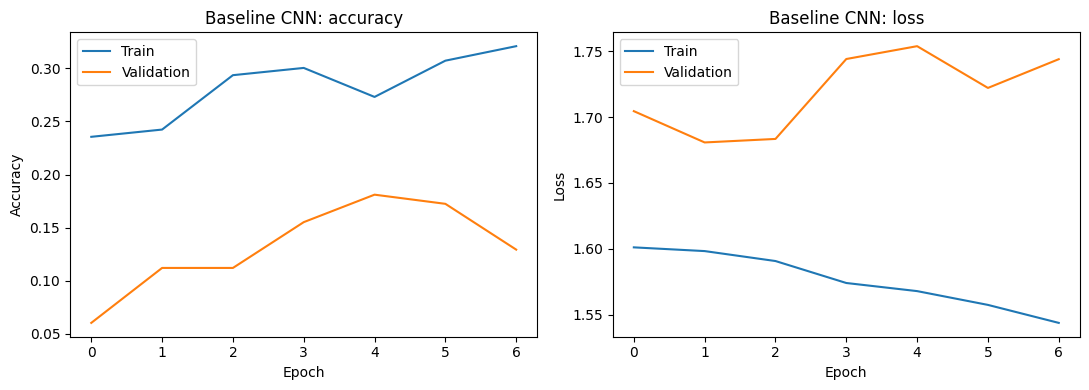

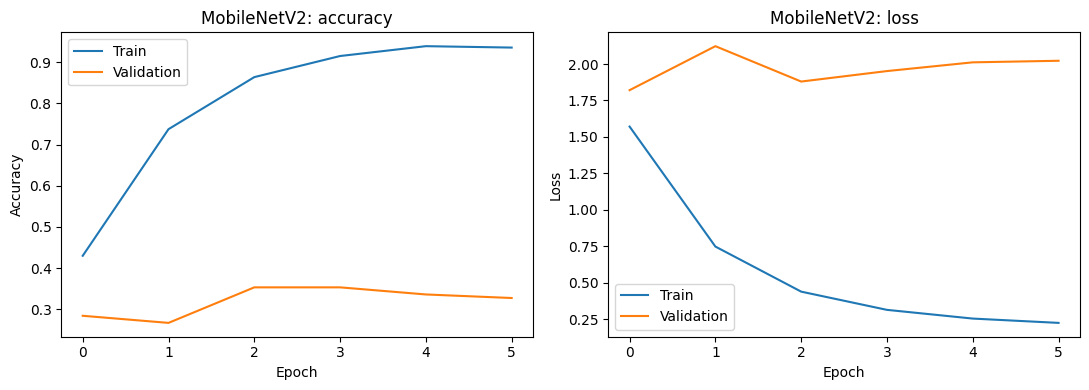

In [ ]:
def plot_history(history, title, filename):
    values = history.history
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(values["accuracy"], label="Train")
    axes[0].plot(values["val_accuracy"], label="Validation")
    axes[0].set_title(f"{title}: accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(values["loss"], label="Train")
    axes[1].plot(values["val_loss"], label="Validation")
    axes[1].set_title(f"{title}: loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(OUTPUT / filename, dpi=180)
    plt.show()

plot_history(
    history_baseline, "Baseline CNN", "baseline_learning_curves.png"
)
plot_history(
    history_transfer, "MobileNetV2", "transfer_learning_curves.png"
)

9. Model Selection

The saved models are compared using validation macro F1-score,
which gives equal weight to each gesture class. The model with the
higher validation macro F1-score is selected before examining
test performance.

In [ ]:
models = {
    "Baseline CNN": keras.models.load_model(OUTPUT / "baseline_cnn.keras"),
    "MobileNetV2": keras.models.load_model(OUTPUT / "mobilenetv2.keras")
}

validation_rows = []

for name, model in models.items():
    predictions = model.predict(val_ds, verbose=0).argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        val_df["label"],
        predictions,
        labels=list(range(NUM_CLASSES)),
        average="macro",
        zero_division=0
    )

    validation_rows.append({
        "model": name,
        "accuracy": accuracy_score(val_df["label"], predictions),
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    })

validation_results = pd.DataFrame(validation_rows)
display(validation_results.round(4))

selected_name = validation_results.loc[
    validation_results["f1_macro"].idxmax(), "model"
]

print("Selected using validation macro F1:", selected_name)

validation_results.to_csv(
    OUTPUT / "validation_comparison.csv", index=False
)

with open(OUTPUT / "selected_model.json", "w") as f:
    json.dump({
        "model": selected_name,
        "selection_metric": "validation macro F1"
    }, f, indent=2)

,model,accuracy,precision_macro,recall_macro,f1_macro
0,Baseline CNN,0.1121,0.0224,0.2000,0.0403
1,MobileNetV2,0.2845,0.2845,0.3721,0.2613


Selected using validation macro F1: MobileNetV2


10. Test Set Evaluation

Both models are evaluated on the held-out participant, person_003.
Accuracy, macro precision, macro recall, and macro F1-score are
reported. Confusion matrices show which gestures are confused.

Test results are used for final reporting, not for tuning the models.


MODEL: Baseline CNN
              precision    recall  f1-score   support

      fist ✊      0.000     0.000     0.000         5
 open_palm ✋      0.000     0.000     0.000        26
    peace ✌️      0.000     0.000     0.000        35
  point_up 👆      0.089     1.000     0.164         9
  thumbs_up👍      0.000     0.000     0.000        26

    accuracy                          0.089       101
   macro avg      0.018     0.200     0.033       101
weighted avg      0.008     0.089     0.015       101



/tmp/ipykernel_828/980125775.py:61: UserWarning: Glyph 9994 (\N{RAISED FIST}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/980125775.py:61: UserWarning: Glyph 9995 (\N{RAISED HAND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/980125775.py:61: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/980125775.py:61: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/980125775.py:62: UserWarning: Glyph 9994 (\N{RAISED FIST}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT / f"{slug}_confusion_matrix.png", dpi=180)
/tmp/ipykernel_828/980125775.py:62: UserWarning: Glyph 9995 (\N{RAISED HAND}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT / f"{slug}_confusion_matrix.png", dpi=180)
/tmp/ipykernel_828/980125775.py:62: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACK

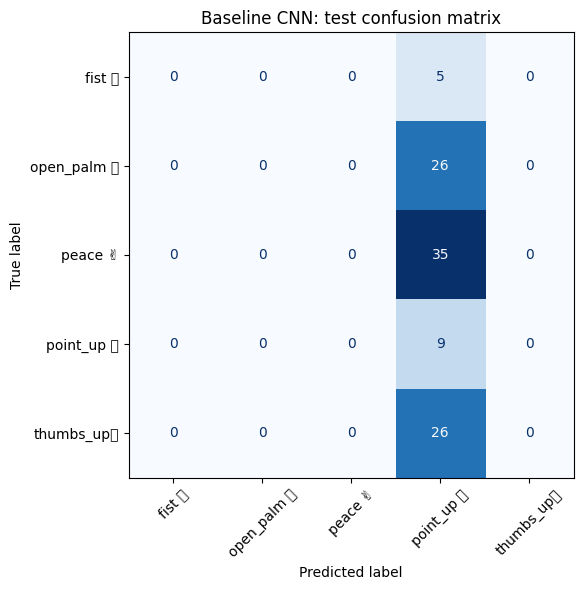


MODEL: MobileNetV2
              precision    recall  f1-score   support

      fist ✊      0.100     0.400     0.160         5
 open_palm ✋      0.250     0.154     0.190        26
    peace ✌️      0.200     0.114     0.145        35
  point_up 👆      0.156     0.556     0.244         9
  thumbs_up👍      0.385     0.192     0.256        26

    accuracy                          0.198       101
   macro avg      0.218     0.283     0.199       101
weighted avg      0.252     0.198     0.195       101



/tmp/ipykernel_828/980125775.py:61: UserWarning: Glyph 9994 (\N{RAISED FIST}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/980125775.py:61: UserWarning: Glyph 9995 (\N{RAISED HAND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/980125775.py:61: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACKHAND INDEX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/980125775.py:61: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/980125775.py:62: UserWarning: Glyph 9994 (\N{RAISED FIST}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT / f"{slug}_confusion_matrix.png", dpi=180)
/tmp/ipykernel_828/980125775.py:62: UserWarning: Glyph 9995 (\N{RAISED HAND}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT / f"{slug}_confusion_matrix.png", dpi=180)
/tmp/ipykernel_828/980125775.py:62: UserWarning: Glyph 128070 (\N{WHITE UP POINTING BACK

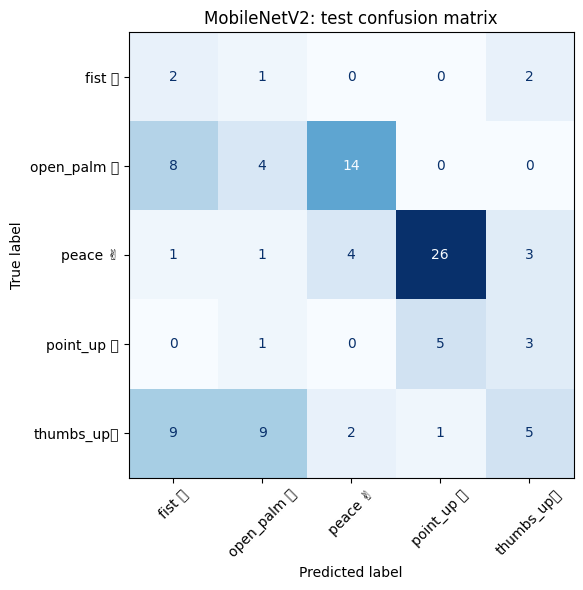

,model,accuracy,precision_macro,recall_macro,f1_macro
0,Baseline CNN,0.0891,0.0178,0.2000,0.0327
1,MobileNetV2,0.1980,0.2182,0.2832,0.1992


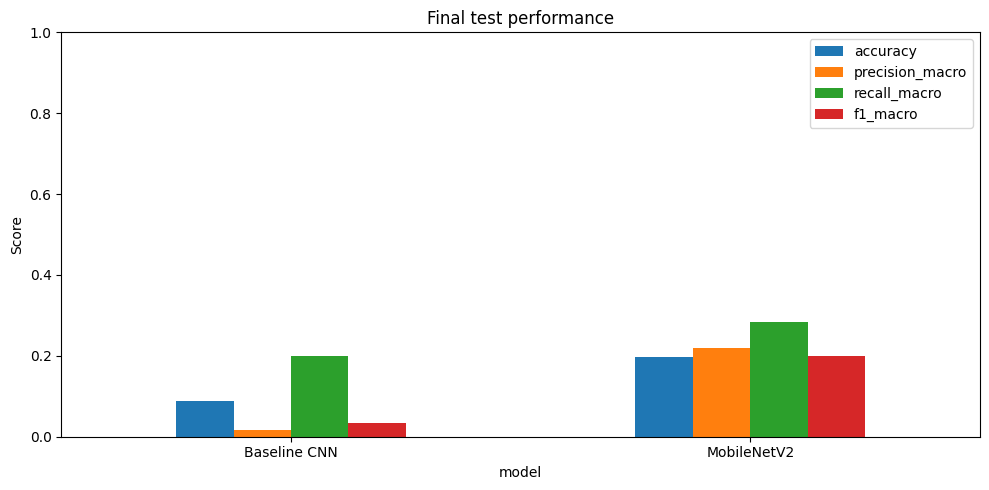

In [ ]:
test_rows = []
test_predictions = {}

for name, model in models.items():
    probabilities = model.predict(test_ds, verbose=0)
    predictions = probabilities.argmax(axis=1)
    test_predictions[name] = predictions

    precision, recall, f1, _ = precision_recall_fscore_support(
        test_df["label"],
        predictions,
        labels=list(range(NUM_CLASSES)),
        average="macro",
        zero_division=0
    )

    test_rows.append({
        "model": name,
        "accuracy": accuracy_score(test_df["label"], predictions),
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    })

    print("\nMODEL:", name)
    print(classification_report(
        test_df["label"],
        predictions,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES,
        zero_division=0,
        digits=3
    ))

    report = classification_report(
        test_df["label"],
        predictions,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES,
        zero_division=0,
        output_dict=True
    )

    slug = name.lower().replace(" ", "_")
    pd.DataFrame(report).transpose().to_csv(
        OUTPUT / f"{slug}_classification_report.csv"
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        test_df["label"],
        predictions,
        labels=list(range(NUM_CLASSES)),
        display_labels=CLASS_NAMES,
        cmap="Blues",
        xticks_rotation=45,
        colorbar=False,
        ax=ax
    )
    ax.set_title(f"{name}: test confusion matrix")
    plt.tight_layout()
    plt.savefig(OUTPUT / f"{slug}_confusion_matrix.png", dpi=180)
    plt.show()

    prediction_table = test_df[["source", "class_name"]].copy()
    prediction_table["predicted_class"] = [
        CLASS_NAMES[i] for i in predictions
    ]
    prediction_table["confidence"] = probabilities.max(axis=1)
    prediction_table.to_csv(
        OUTPUT / f"{slug}_test_predictions.csv", index=False
    )

test_results = pd.DataFrame(test_rows)
display(test_results.round(4))
test_results.to_csv(OUTPUT / "test_comparison.csv", index=False)

test_results.set_index("model").plot.bar(
    figsize=(10, 5), ylim=(0, 1), rot=0
)
plt.title("Final test performance")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig(OUTPUT / "model_comparison.png", dpi=180)
plt.show()

11. Error Analysis

Misclassified test images are inspected to identify possible sources
of difficulty, including similar finger positions, lighting, background,
and hand orientation. These observations suggest possible explanations
rather than proving the cause of each error.

/tmp/ipykernel_828/3292873524.py:28: UserWarning: Glyph 9994 (\N{RAISED FIST}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/3292873524.py:28: UserWarning: Glyph 9995 (\N{RAISED HAND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/3292873524.py:28: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_828/3292873524.py:29: UserWarning: Glyph 9994 (\N{RAISED FIST}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT / "misclassified_examples.png", dpi=180)
/tmp/ipykernel_828/3292873524.py:29: UserWarning: Glyph 9995 (\N{RAISED HAND}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT / "misclassified_examples.png", dpi=180)
/tmp/ipykernel_828/3292873524.py:29: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT / "misclassified_examples.png", dpi=180)


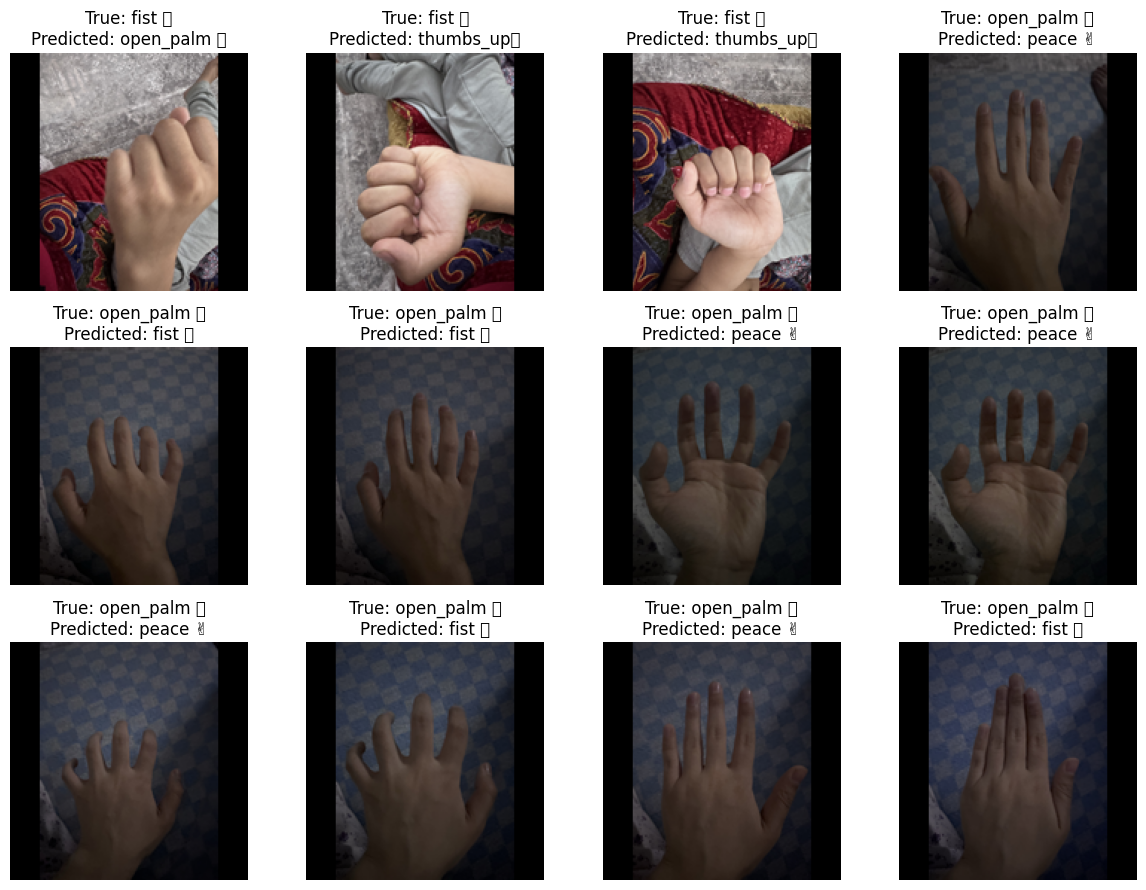

In [ ]:
predictions = test_predictions[selected_name]
true_labels = test_df["label"].to_numpy()

wrong_indices = np.flatnonzero(predictions != true_labels)

if len(wrong_indices) == 0:
    print("No errors on this test split.")
    print("This does not prove perfect performance on new people or settings.")
else:
    chosen = wrong_indices[:12]
    rows = int(np.ceil(len(chosen) / 4))

    fig, axes = plt.subplots(rows, 4, figsize=(12, 3 * rows))
    axes = np.asarray(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, index in zip(axes, chosen):
        with Image.open(test_df.iloc[index]["path"]) as im:
            ax.imshow(im)

        ax.set_title(
            f"True: {CLASS_NAMES[true_labels[index]]}\n"
            f"Predicted: {CLASS_NAMES[predictions[index]]}"
        )

    plt.tight_layout()
    plt.savefig(OUTPUT / "misclassified_examples.png", dpi=180)
    plt.show()

Prediction on a New Image

The selected model is used to predict the gesture in an uploaded
image. The same resizing and normalization pipeline is applied.
The model always predicts one of the five known classes and cannot
reliably reject unrelated images or unknown gestures.

In [ ]:
from google.colab import files

uploaded = files.upload()
selected_model = models[selected_name]

for filename, content in uploaded.items():
    import io

    with Image.open(io.BytesIO(content)) as original:
        image = ImageOps.exif_transpose(original).convert("RGB")
        image = ImageOps.pad(
            image, IMG_SIZE,
            method=Image.Resampling.LANCZOS,
            color=(0, 0, 0)
        )

    array = np.asarray(image, dtype=np.float32)[None, ...]
    probabilities = selected_model.predict(array, verbose=0)[0]
    predicted_index = int(probabilities.argmax())

    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"{CLASS_NAMES[predicted_index]} "
        f"({probabilities[predicted_index]:.1%})"
    )
    plt.show()

    display(pd.DataFrame({
        "class": CLASS_NAMES,
        "probability": probabilities
    }).sort_values("probability", ascending=False))

### Saving the Experiment

Model checkpoints, training histories, evaluation metrics, figures,
class names, and the split manifest are saved to Google Drive.
The experiment configuration records the main training settings.

In [ ]:
configuration = {
    "seed": SEED,
    "image_size": list(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "classes": CLASS_NAMES,
    "group_split": USE_GROUPS,
    "train_images": len(train_df),
    "validation_images": len(val_df),
    "test_images": len(test_df),
    "selected_model": selected_name,
    "selection_metric": "validation macro F1",
    "tensorflow_version": tf.__version__,
    "baseline_max_epochs": 25,
    "transfer_max_epochs": 25,
    "baseline_epochs_run": len(history_baseline.history["loss"]),
    "transfer_epochs_run": len(history_transfer.history["loss"]),
    "transfer_backbone": "MobileNetV2",
    "pretrained_weights": "ImageNet",
    "backbone_frozen": True
}

with open(OUTPUT / "experiment_config.json", "w") as f:
    json.dump(configuration, f, indent=2)

archive_path = shutil.make_archive(
    str(PROJECT / f"results_{RUN_ID}"),
    "zip",
    root_dir=str(OUTPUT)
)

print("Results folder:", OUTPUT)
print("Results ZIP:", archive_path)
print("Keep the original dataset ZIP separately.")

### Limitations

The dataset contains only three participants, with one participant
used for each subset. Training on one person limits the diversity
available to the models, and testing on one held-out person provides
only a limited assessment of generalization.

Additional participants, collection sessions, and backgrounds are
needed for a more reliable evaluation. This project classifies
five static gestures; it does not translate sign language.

In [ ]:
print("DATASET AND SPLIT")
display(split_counts)

print("\nVALIDATION RESULTS")
display(validation_results.round(4))

print("\nTEST RESULTS")
display(test_results.round(4))

print("\nSELECTED MODEL:", selected_name)

print("\nDATA CHECK")
print("Usable images:", len(df))
print("Excluded files / issues:", len(issues))